In [1]:

# Load and explore the research program to understand the previous analyses
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Let's check if there are any existing data files
for root, dirs, files in os.walk('.'):
 for file in files[:20]: # First 20 files
 print(os.path.join(root, file))


./research-program-v3.pdf
./main.pdf
./.config/matplotlib/matplotlibrc
./.config/matplotlib/fontlist-v390.json


In [2]:

# Based on the research program, I need to perform a fine-grained scan for L_DH^(ε=-0.05)
# with N=10^6 in the interval [80.5, 81.5] with step size Δt=0.001

# Key implementation details from the research program:
# 1. L_DH coefficients must be zero for non-squarefree numbers (μ(n)=0)
# 2. Use Kahan compensated summation for numerical precision
# 3. For perturbed L_DH: κ' = κ + ε where ε = -0.05
# 4. Compute both |D(t)| and R_comp metrics

import numpy as np
from scipy import stats
from scipy.special import factorial
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
import warnings
warnings.filterwarnings('ignore')

# First, let's implement the necessary functions
print("Setting up analysis for L_DH^(ε=-0.05) fine-grained scan")
print("=" * 70)
print("Target: N = 10^6, t ∈ [80.5, 81.5], Δt = 0.001")
print("Based on coarse scan peak at t* ≈ 80.86")


Setting up analysis for L_DH^(ε=-0.05) fine-grained scan
Target: N = 10^6, t ∈ [80.5, 81.5], Δt = 0.001
Based on coarse scan peak at t* ≈ 80.86


In [3]:

# Define the Davenport-Heilbronn function with perturbation ε = -0.05
# Following the research program specifications

# Define κ and θ for the Davenport-Heilbronn function
kappa_base = (np.sqrt(5) - 1) / (2 * np.sqrt(5 * (np.sqrt(5) - 1)))
print(f"Base κ = {kappa_base:.10f}")

# Perturbed κ with ε = -0.05
epsilon = -0.05
kappa = kappa_base + epsilon
print(f"Perturbed κ (ε={epsilon}) = {kappa:.10f}")

# Character χ modulo 5 (primitive complex character of order 4)
# χ(1) = 1, χ(2) = i, χ(3) = -i, χ(4) = -1, χ(0) = 0
def chi_mod5(n):
 """Complex character χ modulo 5"""
 n_mod = n % 5
 if n_mod == 0:
 return 0.0 + 0.0j
 elif n_mod == 1:
 return 1.0 + 0.0j
 elif n_mod == 2:
 return 0.0 + 1.0j
 elif n_mod == 3:
 return 0.0 - 1.0j
 elif n_mod == 4:
 return -1.0 + 0.0j

# Test the character
print("\nTesting χ modulo 5:")
for n in range(1, 6):
 print(f" χ({n}) = {chi_mod5(n)}")


Base κ = 0.2486028939
Perturbed κ (ε=-0.05) = 0.1986028939

Testing χ modulo 5:
 χ(1) = (1+0j)
 χ(2) = 1j
 χ(3) = -1j
 χ(4) = (-1+0j)
 χ(5) = 0j


In [4]:

# Implement Möbius function to identify squarefree numbers
@njit
def mobius(n):
 """
 Compute the Möbius function μ(n)
 Returns:
 1 if n is squarefree with even number of prime factors
 -1 if n is squarefree with odd number of prime factors
 0 if n has a squared prime factor
 """
 if n == 1:
 return 1
 
 # Factor n
 num_factors = 0
 temp = n
 
 # Check for factor of 2
 if temp % 2 == 0:
 num_factors += 1
 temp //= 2
 if temp % 2 == 0: # Has 2^2 as factor
 return 0
 
 # Check odd factors
 d = 3
 while d * d <= temp:
 if temp % d == 0:
 num_factors += 1
 temp //= d
 if temp % d == 0: # Has d^2 as factor
 return 0
 d += 2
 
 if temp > 1:
 num_factors += 1
 
 return 1 if num_factors % 2 == 0 else -1

# Test Möbius function
print("Testing Möbius function μ(n):")
test_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 30]
for n in test_values:
 mu = mobius(n)
 print(f" μ({n:2d}) = {mu:2d}")


Testing Möbius function μ(n):


 μ( 1) = 1
 μ( 2) = -1
 μ( 3) = -1
 μ( 4) = 0
 μ( 5) = -1
 μ( 6) = 1
 μ( 7) = -1
 μ( 8) = 0
 μ( 9) = 0
 μ(10) = 1
 μ(12) = 0
 μ(15) = 1
 μ(30) = -1


In [5]:

# Compute the coefficients a_n for L_DH^(ε=-0.05)
# a_n = ((1-iκ')/2) * χ(n) + ((1+iκ')/2) * χ̄(n)
# CRITICAL: a_n = 0 for non-squarefree n (where μ(n) = 0)

N = 10**6
print(f"Computing L_DH coefficients for N = {N:,}...")

# Pre-compute all coefficients
a_n = np.zeros(N + 1, dtype=np.complex128)

# Coefficients based on perturbed L_DH
coeff1 = (1 - 1j * kappa) / 2
coeff2 = (1 + 1j * kappa) / 2

print(f" Coefficient 1 (1-iκ')/2 = {coeff1}")
print(f" Coefficient 2 (1+iκ')/2 = {coeff2}")

# Compute for each n
count_squarefree = 0
for n in range(1, N + 1):
 mu_n = mobius(n)
 if mu_n != 0: # Only compute for squarefree n
 chi_n = chi_mod5(n)
 chi_bar_n = np.conj(chi_n)
 a_n[n] = coeff1 * chi_n + coeff2 * chi_bar_n
 count_squarefree += 1
 # else: a_n[n] = 0 (already initialized)
 
 if n % 200000 == 0:
 print(f" Progress: {n:,} / {N:,} ({100*n/N:.1f}%)")

print(f"\nCoefficients computed!")
print(f" Squarefree numbers up to {N:,}: {count_squarefree:,} ({100*count_squarefree/N:.2f}%)")
print(f" Expected density (6/π²): {100*6/(np.pi**2):.2f}%")


Computing L_DH coefficients for N = 1,000,000...
 Coefficient 1 (1-iκ')/2 = (0.5-0.0993014469696446j)
 Coefficient 2 (1+iκ')/2 = (0.5+0.0993014469696446j)


 Progress: 200,000 / 1,000,000 (20.0%)


 Progress: 400,000 / 1,000,000 (40.0%)


 Progress: 600,000 / 1,000,000 (60.0%)


 Progress: 800,000 / 1,000,000 (80.0%)


 Progress: 1,000,000 / 1,000,000 (100.0%)

Coefficients computed!
 Squarefree numbers up to 1,000,000: 607,926 (60.79%)
 Expected density (6/π²): 60.79%


In [6]:

# Verify a few coefficient values
print("Sample L_DH^(ε=-0.05) coefficients:")
print(f" a_1 = {a_n[1]}")
print(f" a_2 = {a_n[2]}")
print(f" a_3 = {a_n[3]}")
print(f" a_4 = {a_n[4]} (should be 0, non-squarefree)")
print(f" a_5 = {a_n[5]}")
print(f" a_6 = {a_n[6]}")
print(f" a_7 = {a_n[7]}")
print(f" a_8 = {a_n[8]} (should be 0, non-squarefree)")
print(f" a_9 = {a_n[9]} (should be 0, non-squarefree)")
print(f" a_10 = {a_n[10]}")


Sample L_DH^(ε=-0.05) coefficients:
 a_1 = (1+0j)
 a_2 = (0.1986028939392892+0j)
 a_3 = (-0.1986028939392892+0j)
 a_4 = 0j (should be 0, non-squarefree)
 a_5 = 0j
 a_6 = (1+0j)
 a_7 = (0.1986028939392892+0j)
 a_8 = 0j (should be 0, non-squarefree)
 a_9 = 0j (should be 0, non-squarefree)
 a_10 = 0j


In [7]:

# Implement Kahan compensated summation for high numerical precision
@njit
def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex values
 Reduces rounding error from O(ε*N) to O(ε*log(N))
 """
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j # Compensation for lost low-order bits
 
 for val in values:
 y = val - c
 t = total + y
 c = (t - total) - y
 total = t
 
 return total

# Implement the partial sum D(t; N) with Kahan summation
@njit
def compute_D_kahan(a_n, t, N):
 """
 Compute D(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 using Kahan compensated summation
 
 D(t; N) = Σ_{n≤N} a_n * n^(-1/2) * exp(-it*log(n))
 """
 terms = np.empty(N, dtype=np.complex128)
 
 for n in range(1, N + 1):
 if a_n[n] != 0.0: # Skip zero coefficients
 n_sqrt_inv = 1.0 / np.sqrt(float(n))
 phase = np.exp(-1j * t * np.log(float(n)))
 terms[n-1] = a_n[n] * n_sqrt_inv * phase
 else:
 terms[n-1] = 0.0 + 0.0j
 
 return kahan_sum_complex(terms)

print("Kahan summation implementation ready")
print("Testing D(t) computation...")

# Test at a sample point
t_test = 80.86
D_test = compute_D_kahan(a_n, t_test, N)
print(f"\nTest: D(t={t_test}) = {D_test}")
print(f" |D(t={t_test})| = {np.abs(D_test):.6f}")


Kahan summation implementation ready
Testing D(t) computation...



Test: D(t=80.86) = (3.4405492475673745+0.8373029824358016j)
 |D(t=80.86)| = 3.540968


In [8]:

# Now implement the R_comp metric (mean resultant length for composite squarefree terms)
# R_comp measures the coherence of phases for composite squarefree numbers

@njit
def count_prime_factors(n):
 """Count the number of distinct prime factors ω(n)"""
 if n == 1:
 return 0
 
 count = 0
 temp = n
 
 # Check for factor of 2
 if temp % 2 == 0:
 count += 1
 while temp % 2 == 0:
 temp //= 2
 
 # Check odd factors
 d = 3
 while d * d <= temp:
 if temp % d == 0:
 count += 1
 while temp % d == 0:
 temp //= d
 d += 2
 
 if temp > 1:
 count += 1
 
 return count

@njit
def compute_R_comp(a_n, t, N):
 """
 Compute R_comp: mean resultant length for composite squarefree terms
 
 Composite squarefree numbers are those with ω(n) ≥ 2 and μ(n) ≠ 0
 
 R_comp = |Σ_{composite squarefree} a_n * n^(-1/2) * exp(-it*log(n))| / 
 Σ_{composite squarefree} |a_n| * n^(-1/2)
 """
 numerator_terms = []
 denominator = 0.0
 
 for n in range(1, N + 1):
 mu_n = mobius(n)
 if mu_n != 0: # Squarefree
 omega_n = count_prime_factors(n)
 if omega_n >= 2: # Composite
 if a_n[n] != 0.0:
 n_sqrt_inv = 1.0 / np.sqrt(float(n))
 phase = np.exp(-1j * t * np.log(float(n)))
 numerator_terms.append(a_n[n] * n_sqrt_inv * phase)
 denominator += np.abs(a_n[n]) * n_sqrt_inv
 
 if len(numerator_terms) == 0 or denominator == 0.0:
 return 0.0
 
 # Use Kahan summation for numerator
 numerator = kahan_sum_complex(np.array(numerator_terms))
 
 return np.abs(numerator) / denominator

print("R_comp implementation ready")
print("Testing R_comp computation...")

# Test at the same point
R_comp_test = compute_R_comp(a_n, t_test, N)
print(f"\nTest: R_comp(t={t_test}) = {R_comp_test:.6f}")


R_comp implementation ready
Testing R_comp computation...



Test: R_comp(t=80.86) = 0.003165


In [9]:

# Now perform the fine-grained scan over t ∈ [80.5, 81.5] with Δt = 0.001
t_min = 80.5
t_max = 81.5
dt = 0.001

t_values = np.arange(t_min, t_max + dt/2, dt) # Include t_max
n_points = len(t_values)

print(f"Fine-grained scan configuration:")
print(f" t range: [{t_min}, {t_max}]")
print(f" Step size: Δt = {dt}")
print(f" Number of points: {n_points}")
print(f" N = {N:,}")
print(f"\nStarting computation...")
print(f" Estimated time: ~{n_points * 5 / 60:.1f} minutes (assuming ~5 sec per point)")
print()

# Compute both metrics for all t values
D_mag = np.zeros(n_points)
R_comp_values = np.zeros(n_points)

import time
start_time = time.time()

for i, t in enumerate(t_values):
 D_t = compute_D_kahan(a_n, t, N)
 D_mag[i] = np.abs(D_t)
 R_comp_values[i] = compute_R_comp(a_n, t, N)
 
 if (i + 1) % 100 == 0:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (n_points - i - 1) / rate
 print(f" Progress: {i+1:4d}/{n_points} ({100*(i+1)/n_points:5.1f}%) - "
 f"Elapsed: {elapsed/60:5.1f} min, ETA: {remaining/60:5.1f} min")

total_time = time.time() - start_time
print(f"\nComputation complete!")
print(f" Total time: {total_time/60:.2f} minutes ({total_time/n_points:.2f} sec/point)")


Fine-grained scan configuration:
 t range: [80.5, 81.5]
 Step size: Δt = 0.001
 Number of points: 1001
 N = 1,000,000

Starting computation...
 Estimated time: ~83.4 minutes (assuming ~5 sec per point)



 Progress: 100/1001 ( 10.0%) - Elapsed: 1.0 min, ETA: 9.0 min


 Progress: 200/1001 ( 20.0%) - Elapsed: 2.0 min, ETA: 8.0 min


 Progress: 300/1001 ( 30.0%) - Elapsed: 3.0 min, ETA: 7.0 min


 Progress: 400/1001 ( 40.0%) - Elapsed: 4.0 min, ETA: 6.0 min


...

 Progress: 700/1001 ( 69.9%) - Elapsed: 7.0 min, ETA: 3.0 min


 Progress: 800/1001 ( 79.9%) - Elapsed: 8.0 min, ETA: 2.0 min


 Progress: 900/1001 ( 89.9%) - Elapsed: 9.0 min, ETA: 1.0 min


 Progress: 1000/1001 ( 99.9%) - Elapsed: 10.0 min, ETA: 0.0 min



Computation complete!
 Total time: 10.03 minutes (0.60 sec/point)


In [10]:

# Identify the peak locations for both metrics
idx_D_max = np.argmax(D_mag)
idx_R_max = np.argmax(R_comp_values)

t_D = t_values[idx_D_max]
t_R = t_values[idx_R_max]

D_max = D_mag[idx_D_max]
R_comp_max = R_comp_values[idx_R_max]

print("=" * 70)
print("PEAK LOCATIONS IDENTIFIED")
print("=" * 70)
print(f"\n|D(t)| peak:")
print(f" t_D = {t_D:.3f}")
print(f" |D(t_D)| = {D_max:.6f}")
print(f" R_comp(t_D) = {R_comp_values[idx_D_max]:.6f}")

print(f"\nR_comp peak:")
print(f" t_R = {t_R:.3f}")
print(f" R_comp(t_R) = {R_comp_max:.6f}")
print(f" |D(t_R)| = {D_mag[idx_R_max]:.6f}")

print(f"\nPeak separation:")
print(f" |t_R - t_D| = {np.abs(t_R - t_D):.3f}")

# Statistical summary
print(f"\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)
print(f"\n|D(t)| statistics:")
print(f" Mean: {np.mean(D_mag):.6f}")
print(f" Std: {np.std(D_mag):.6f}")
print(f" Max: {np.max(D_mag):.6f}")
print(f" Min: {np.min(D_mag):.6f}")

print(f"\nR_comp statistics:")
print(f" Mean: {np.mean(R_comp_values):.6f}")
print(f" Std: {np.std(R_comp_values):.6f}")
print(f" Max: {np.max(R_comp_values):.6f}")
print(f" Min: {np.min(R_comp_values):.6f}")


PEAK LOCATIONS IDENTIFIED

|D(t)| peak:
 t_D = 80.852
 |D(t_D)| = 3.542371
 R_comp(t_D) = 0.003148

R_comp peak:
 t_R = 80.910
 R_comp(t_R) = 0.003213
 |D(t_R)| = 3.465312

Peak separation:
 |t_R - t_D| = 0.058

STATISTICAL SUMMARY

|D(t)| statistics:
 Mean: 2.374725
 Std: 0.804069
 Max: 3.542371
 Min: 1.233589

R_comp statistics:
 Mean: 0.002042
 Std: 0.000940
 Max: 0.003213
 Min: 0.000283


In [11]:

# Compute signal-to-noise ratios for both metrics
# SNR = (peak - mean) / std

SNR_D = (D_max - np.mean(D_mag)) / np.std(D_mag)
SNR_R = (R_comp_max - np.mean(R_comp_values)) / np.std(R_comp_values)

print("Signal-to-Noise Ratios:")
print(f" SNR(|D(t)|) = {SNR_D:.3f}")
print(f" SNR(R_comp) = {SNR_R:.3f}")
print(f"\nComparison:")
print(f" R_comp has {SNR_R/SNR_D:.2f}× higher SNR than |D(t)|")


Signal-to-Noise Ratios:
 SNR(|D(t)|) = 1.452
 SNR(R_comp) = 1.245

Comparison:
 R_comp has 0.86× higher SNR than |D(t)|


In [12]:

# Now perform Rayleigh tests at both peak locations
# The Rayleigh test checks for non-uniformity of phase distribution

@njit
def compute_phases_composite_squarefree(a_n, t, N):
 """
 Compute phases θ_n = arg(a_n * n^(-1/2) * exp(-it*log(n))) 
 for composite squarefree terms
 """
 phases = []
 
 for n in range(1, N + 1):
 mu_n = mobius(n)
 if mu_n != 0: # Squarefree
 omega_n = count_prime_factors(n)
 if omega_n >= 2: # Composite
 if a_n[n] != 0.0:
 n_sqrt_inv = 1.0 / np.sqrt(float(n))
 phase_factor = np.exp(-1j * t * np.log(float(n)))
 complex_val = a_n[n] * n_sqrt_inv * phase_factor
 phase = np.angle(complex_val)
 phases.append(phase)
 
 return np.array(phases)

def rayleigh_test(phases):
 """
 Rayleigh test for non-uniformity of circular data
 Returns: (R, p_value, n)
 where R is mean resultant length and p is significance
 """
 n = len(phases)
 if n == 0:
 return 0.0, 1.0, 0
 
 # Convert phases to unit vectors and compute mean resultant
 C = np.sum(np.cos(phases))
 S = np.sum(np.sin(phases))
 R = np.sqrt(C**2 + S**2) / n # Mean resultant length
 
 # Rayleigh test statistic
 Z = n * R**2
 
 # P-value approximation (valid for n > 50)
 # p ≈ exp(-Z) for large n
 if n > 50:
 p_value = np.exp(-Z)
 # More accurate approximation
 p_value = np.exp(-Z) * (1 + (2*Z - Z**2) / (4*n) - (24*Z - 132*Z**2 + 76*Z**3 - 9*Z**4) / (288*n**2))
 else:
 # For small n, use exact distribution
 from scipy.stats import rayleigh
 p_value = np.exp(-Z)
 
 return R, p_value, n

print("Computing Rayleigh tests at peak locations...")
print()

# Test at t_D (|D(t)| peak)
phases_D = compute_phases_composite_squarefree(a_n, t_D, N)
R_D, p_D, n_D = rayleigh_test(phases_D)

print(f"Rayleigh test at t_D = {t_D:.3f} (|D(t)| peak):")
print(f" Number of composite squarefree terms: {n_D:,}")
print(f" Mean resultant length R: {R_D:.6f}")
print(f" P-value: {p_D:.2e}")
print(f" Significant (p < 0.05): {'YES' if p_D < 0.05 else 'NO'}")

print()

# Test at t_R (R_comp peak)
phases_R = compute_phases_composite_squarefree(a_n, t_R, N)
R_R, p_R, n_R = rayleigh_test(phases_R)

print(f"Rayleigh test at t_R = {t_R:.3f} (R_comp peak):")
print(f" Number of composite squarefree terms: {n_R:,}")
print(f" Mean resultant length R: {R_R:.6f}")
print(f" P-value: {p_R:.2e}")
print(f" Significant (p < 0.05): {'YES' if p_R < 0.05 else 'NO'}")


Computing Rayleigh tests at peak locations...



Rayleigh test at t_D = 80.852 (|D(t)| peak):
 Number of composite squarefree terms: 428,106
 Mean resultant length R: 0.000702
 P-value: 8.10e-01
 Significant (p < 0.05): NO

Rayleigh test at t_R = 80.910 (R_comp peak):
 Number of composite squarefree terms: 428,106
 Mean resultant length R: 0.000646
 P-value: 8.36e-01
 Significant (p < 0.05): NO


In [13]:

# The Rayleigh test is not showing significance. Let me check if I'm computing R correctly
# R_comp should be computed as the mean resultant length, which should match the Rayleigh R

# Let's verify by recomputing R_comp at these points more carefully
print("Verification of R_comp calculation:")
print()

# The issue might be that R_comp uses weighted phases (by |a_n|/sqrt(n))
# while Rayleigh test treats all phases equally

# Let's compute the weighted mean resultant length
def weighted_rayleigh_test(phases, weights):
 """
 Weighted Rayleigh test for non-uniformity
 """
 n = len(phases)
 if n == 0:
 return 0.0, 1.0, 0
 
 # Compute weighted mean resultant
 C = np.sum(weights * np.cos(phases))
 S = np.sum(weights * np.sin(phases))
 W_total = np.sum(weights)
 
 R = np.sqrt(C**2 + S**2) / W_total # Weighted mean resultant length
 
 # For weighted case, the test statistic needs adjustment
 # Use effective sample size
 n_eff = W_total**2 / np.sum(weights**2)
 Z = n_eff * R**2
 
 # P-value
 p_value = np.exp(-Z)
 if n_eff > 50:
 p_value = np.exp(-Z) * (1 + (2*Z - Z**2) / (4*n_eff))
 
 return R, p_value, n_eff

# Recompute with weights
@njit
def compute_phases_and_weights(a_n, t, N):
 """
 Compute phases and weights for composite squarefree terms
 """
 phases_list = []
 weights_list = []
 
 for n in range(1, N + 1):
 mu_n = mobius(n)
 if mu_n != 0: # Squarefree
 omega_n = count_prime_factors(n)
 if omega_n >= 2: # Composite
 if a_n[n] != 0.0:
 n_sqrt_inv = 1.0 / np.sqrt(float(n))
 phase_factor = np.exp(-1j * t * np.log(float(n)))
 complex_val = a_n[n] * n_sqrt_inv * phase_factor
 phase = np.angle(complex_val)
 weight = np.abs(a_n[n]) * n_sqrt_inv
 phases_list.append(phase)
 weights_list.append(weight)
 
 return np.array(phases_list), np.array(weights_list)

print("Weighted Rayleigh test at peak locations:")
print()

# Test at t_D
phases_D, weights_D = compute_phases_and_weights(a_n, t_D, N)
R_D_weighted, p_D_weighted, n_eff_D = weighted_rayleigh_test(phases_D, weights_D)

print(f"At t_D = {t_D:.3f}:")
print(f" Weighted R: {R_D_weighted:.6f}")
print(f" R_comp(t_D) from scan: {R_comp_values[idx_D_max]:.6f}")
print(f" Effective n: {n_eff_D:.0f}")
print(f" P-value: {p_D_weighted:.2e}")
print(f" Significant (p < 0.05): {'YES' if p_D_weighted < 0.05 else 'NO'}")

print()

# Test at t_R
phases_R, weights_R = compute_phases_and_weights(a_n, t_R, N)
R_R_weighted, p_R_weighted, n_eff_R = weighted_rayleigh_test(phases_R, weights_R)

print(f"At t_R = {t_R:.3f}:")
print(f" Weighted R: {R_R_weighted:.6f}")
print(f" R_comp(t_R) from scan: {R_comp_max:.6f}")
print(f" Effective n: {n_eff_R:.0f}")
print(f" P-value: {p_R_weighted:.2e}")
print(f" Significant (p < 0.05): {'YES' if p_R_weighted < 0.05 else 'NO'}")


Verification of R_comp calculation:

Weighted Rayleigh test at peak locations:



At t_D = 80.852:
 Weighted R: 0.003148
 R_comp(t_D) from scan: 0.003148
 Effective n: 105833
 P-value: 3.50e-01
 Significant (p < 0.05): NO

At t_R = 80.910:
 Weighted R: 0.003213
 R_comp(t_R) from scan: 0.003213
 Effective n: 105833
 P-value: 3.35e-01
 Significant (p < 0.05): NO


In [14]:

# The weighted R matches R_comp perfectly, which is good!
# However, the p-values are not significant (p > 0.05)

# This suggests that the resonance at ε=-0.05 is much weaker than at ε=0
# Let's examine the behavior more carefully

# Check if there's a broader region of elevated values
print("Examining resonance structure:")
print()

# Find indices where |D(t)| is above mean + 1 std
threshold_D = np.mean(D_mag) + np.std(D_mag)
high_D_indices = np.where(D_mag > threshold_D)[0]
print(f"|D(t)| above threshold ({threshold_D:.3f}):")
print(f" Number of points: {len(high_D_indices)}")
if len(high_D_indices) > 0:
 print(f" t range: [{t_values[high_D_indices[0]]:.3f}, {t_values[high_D_indices[-1]]:.3f}]")
 print(f" Width: {t_values[high_D_indices[-1]] - t_values[high_D_indices[0]]:.3f}")

print()

# Find indices where R_comp is above mean + 1 std
threshold_R = np.mean(R_comp_values) + np.std(R_comp_values)
high_R_indices = np.where(R_comp_values > threshold_R)[0]
print(f"R_comp above threshold ({threshold_R:.6f}):")
print(f" Number of points: {len(high_R_indices)}")
if len(high_R_indices) > 0:
 print(f" t range: [{t_values[high_R_indices[0]]:.3f}, {t_values[high_R_indices[-1]]:.3f}]")
 print(f" Width: {t_values[high_R_indices[-1]] - t_values[high_R_indices[0]]:.3f}")


Examining resonance structure:

|D(t)| above threshold (3.179):
 Number of points: 253
 t range: [80.729, 80.981]
 Width: 0.252

R_comp above threshold (0.002982):
 Number of points: 224
 t range: [80.800, 81.023]
 Width: 0.223


In [15]:

# Let's check how localized the peaks are by computing the FWHM (full width at half maximum)

# For |D(t)|
D_half_max = (D_max + np.min(D_mag)) / 2
above_half_D = D_mag > D_half_max
# Find contiguous regions
D_regions = []
in_region = False
start_idx = 0
for i in range(len(above_half_D)):
 if above_half_D[i] and not in_region:
 start_idx = i
 in_region = True
 elif not above_half_D[i] and in_region:
 D_regions.append((start_idx, i-1))
 in_region = False
if in_region:
 D_regions.append((start_idx, len(above_half_D)-1))

# For R_comp
R_half_max = (R_comp_max + np.min(R_comp_values)) / 2
above_half_R = R_comp_values > R_half_max
R_regions = []
in_region = False
start_idx = 0
for i in range(len(above_half_R)):
 if above_half_R[i] and not in_region:
 start_idx = i
 in_region = True
 elif not above_half_R[i] and in_region:
 R_regions.append((start_idx, i-1))
 in_region = False
if in_region:
 R_regions.append((start_idx, len(above_half_R)-1))

print("Peak sharpness analysis (FWHM):")
print()
print(f"|D(t)| peak:")
print(f" Half-maximum: {D_half_max:.3f}")
print(f" Number of regions above half-max: {len(D_regions)}")
if D_regions:
 main_region = max(D_regions, key=lambda r: r[1]-r[0])
 width = t_values[main_region[1]] - t_values[main_region[0]]
 print(f" Main region: [{t_values[main_region[0]]:.3f}, {t_values[main_region[1]]:.3f}]")
 print(f" FWHM: {width:.3f}")

print()
print(f"R_comp peak:")
print(f" Half-maximum: {R_half_max:.6f}")
print(f" Number of regions above half-max: {len(R_regions)}")
if R_regions:
 main_region = max(R_regions, key=lambda r: r[1]-r[0])
 width = t_values[main_region[1]] - t_values[main_region[0]]
 print(f" Main region: [{t_values[main_region[0]]:.3f}, {t_values[main_region[1]]:.3f}]")
 print(f" FWHM: {width:.3f}")


Peak sharpness analysis (FWHM):

|D(t)| peak:
 Half-maximum: 2.388
 Number of regions above half-max: 1
 Main region: [80.624, 81.108]
 FWHM: 0.484

R_comp peak:
 Half-maximum: 0.001748
 Number of regions above half-max: 1
 Main region: [80.603, 81.225]
 FWHM: 0.622


In [16]:

# Create a comprehensive summary table
summary_data = {
 'Metric': ['Peak location', 'Peak value', 'Mean', 'Std', 'SNR', 'FWHM', 'Other metric at peak'],
 '|D(t)|': [
 f'{t_D:.3f}',
 f'{D_max:.6f}',
 f'{np.mean(D_mag):.6f}',
 f'{np.std(D_mag):.6f}',
 f'{SNR_D:.3f}',
 f'{0.484:.3f}',
 f'R_comp = {R_comp_values[idx_D_max]:.6f}'
 ],
 'R_comp': [
 f'{t_R:.3f}',
 f'{R_comp_max:.6f}',
 f'{np.mean(R_comp_values):.6f}',
 f'{np.std(R_comp_values):.6f}',
 f'{SNR_R:.3f}',
 f'{0.622:.3f}',
 f'|D| = {D_mag[idx_R_max]:.6f}'
 ]
}

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("COMPREHENSIVE SUMMARY: L_DH^(ε=-0.05) RESONANCE ANALYSIS")
print("=" * 80)
print(df_summary.to_string(index=False))
print()
print(f"Peak separation: |t_R - t_D| = {np.abs(t_R - t_D):.3f}")
print()
print("Rayleigh test results (weighted):")
print(f" At t_D = {t_D:.3f}: R = {R_D_weighted:.6f}, p = {p_D_weighted:.2e}, n_eff = {n_eff_D:.0f}")
print(f" At t_R = {t_R:.3f}: R = {R_R_weighted:.6f}, p = {p_R_weighted:.2e}, n_eff = {n_eff_R:.0f}")
print()
print("Statistical significance: Both p-values > 0.05 (NOT significant)")


COMPREHENSIVE SUMMARY: L_DH^(ε=-0.05) RESONANCE ANALYSIS
 Metric |D(t)| R_comp
 Peak location 80.852 80.910
 Peak value 3.542371 0.003213
 Mean 2.374725 0.002042
 Std 0.804069 0.000940
 SNR 1.452 1.245
 FWHM 0.484 0.622
Other metric at peak R_comp = 0.003148 |D| = 3.465312

Peak separation: |t_R - t_D| = 0.058

Rayleigh test results (weighted):
 At t_D = 80.852: R = 0.003148, p = 3.50e-01, n_eff = 105833
 At t_R = 80.910: R = 0.003213, p = 3.35e-01, n_eff = 105833

Statistical significance: Both p-values > 0.05 (NOT significant)


In [17]:

# Save the results to disk
results_df = pd.DataFrame({
 't': t_values,
 'D_magnitude': D_mag,
 'R_comp': R_comp_values
})

results_df.to_csv('L_DH_eps_minus_0p05_fine_scan_N1e6.csv', index=False)
print("Results saved to: L_DH_eps_minus_0p05_fine_scan_N1e6.csv")
print(f" {len(results_df)} data points")
print(f" Columns: {list(results_df.columns)}")


Results saved to: L_DH_eps_minus_0p05_fine_scan_N1e6.csv
 1001 data points
 Columns: ['t', 'D_magnitude', 'R_comp']


Figure saved: L_DH_eps_minus_0p05_resonance_comparison.png


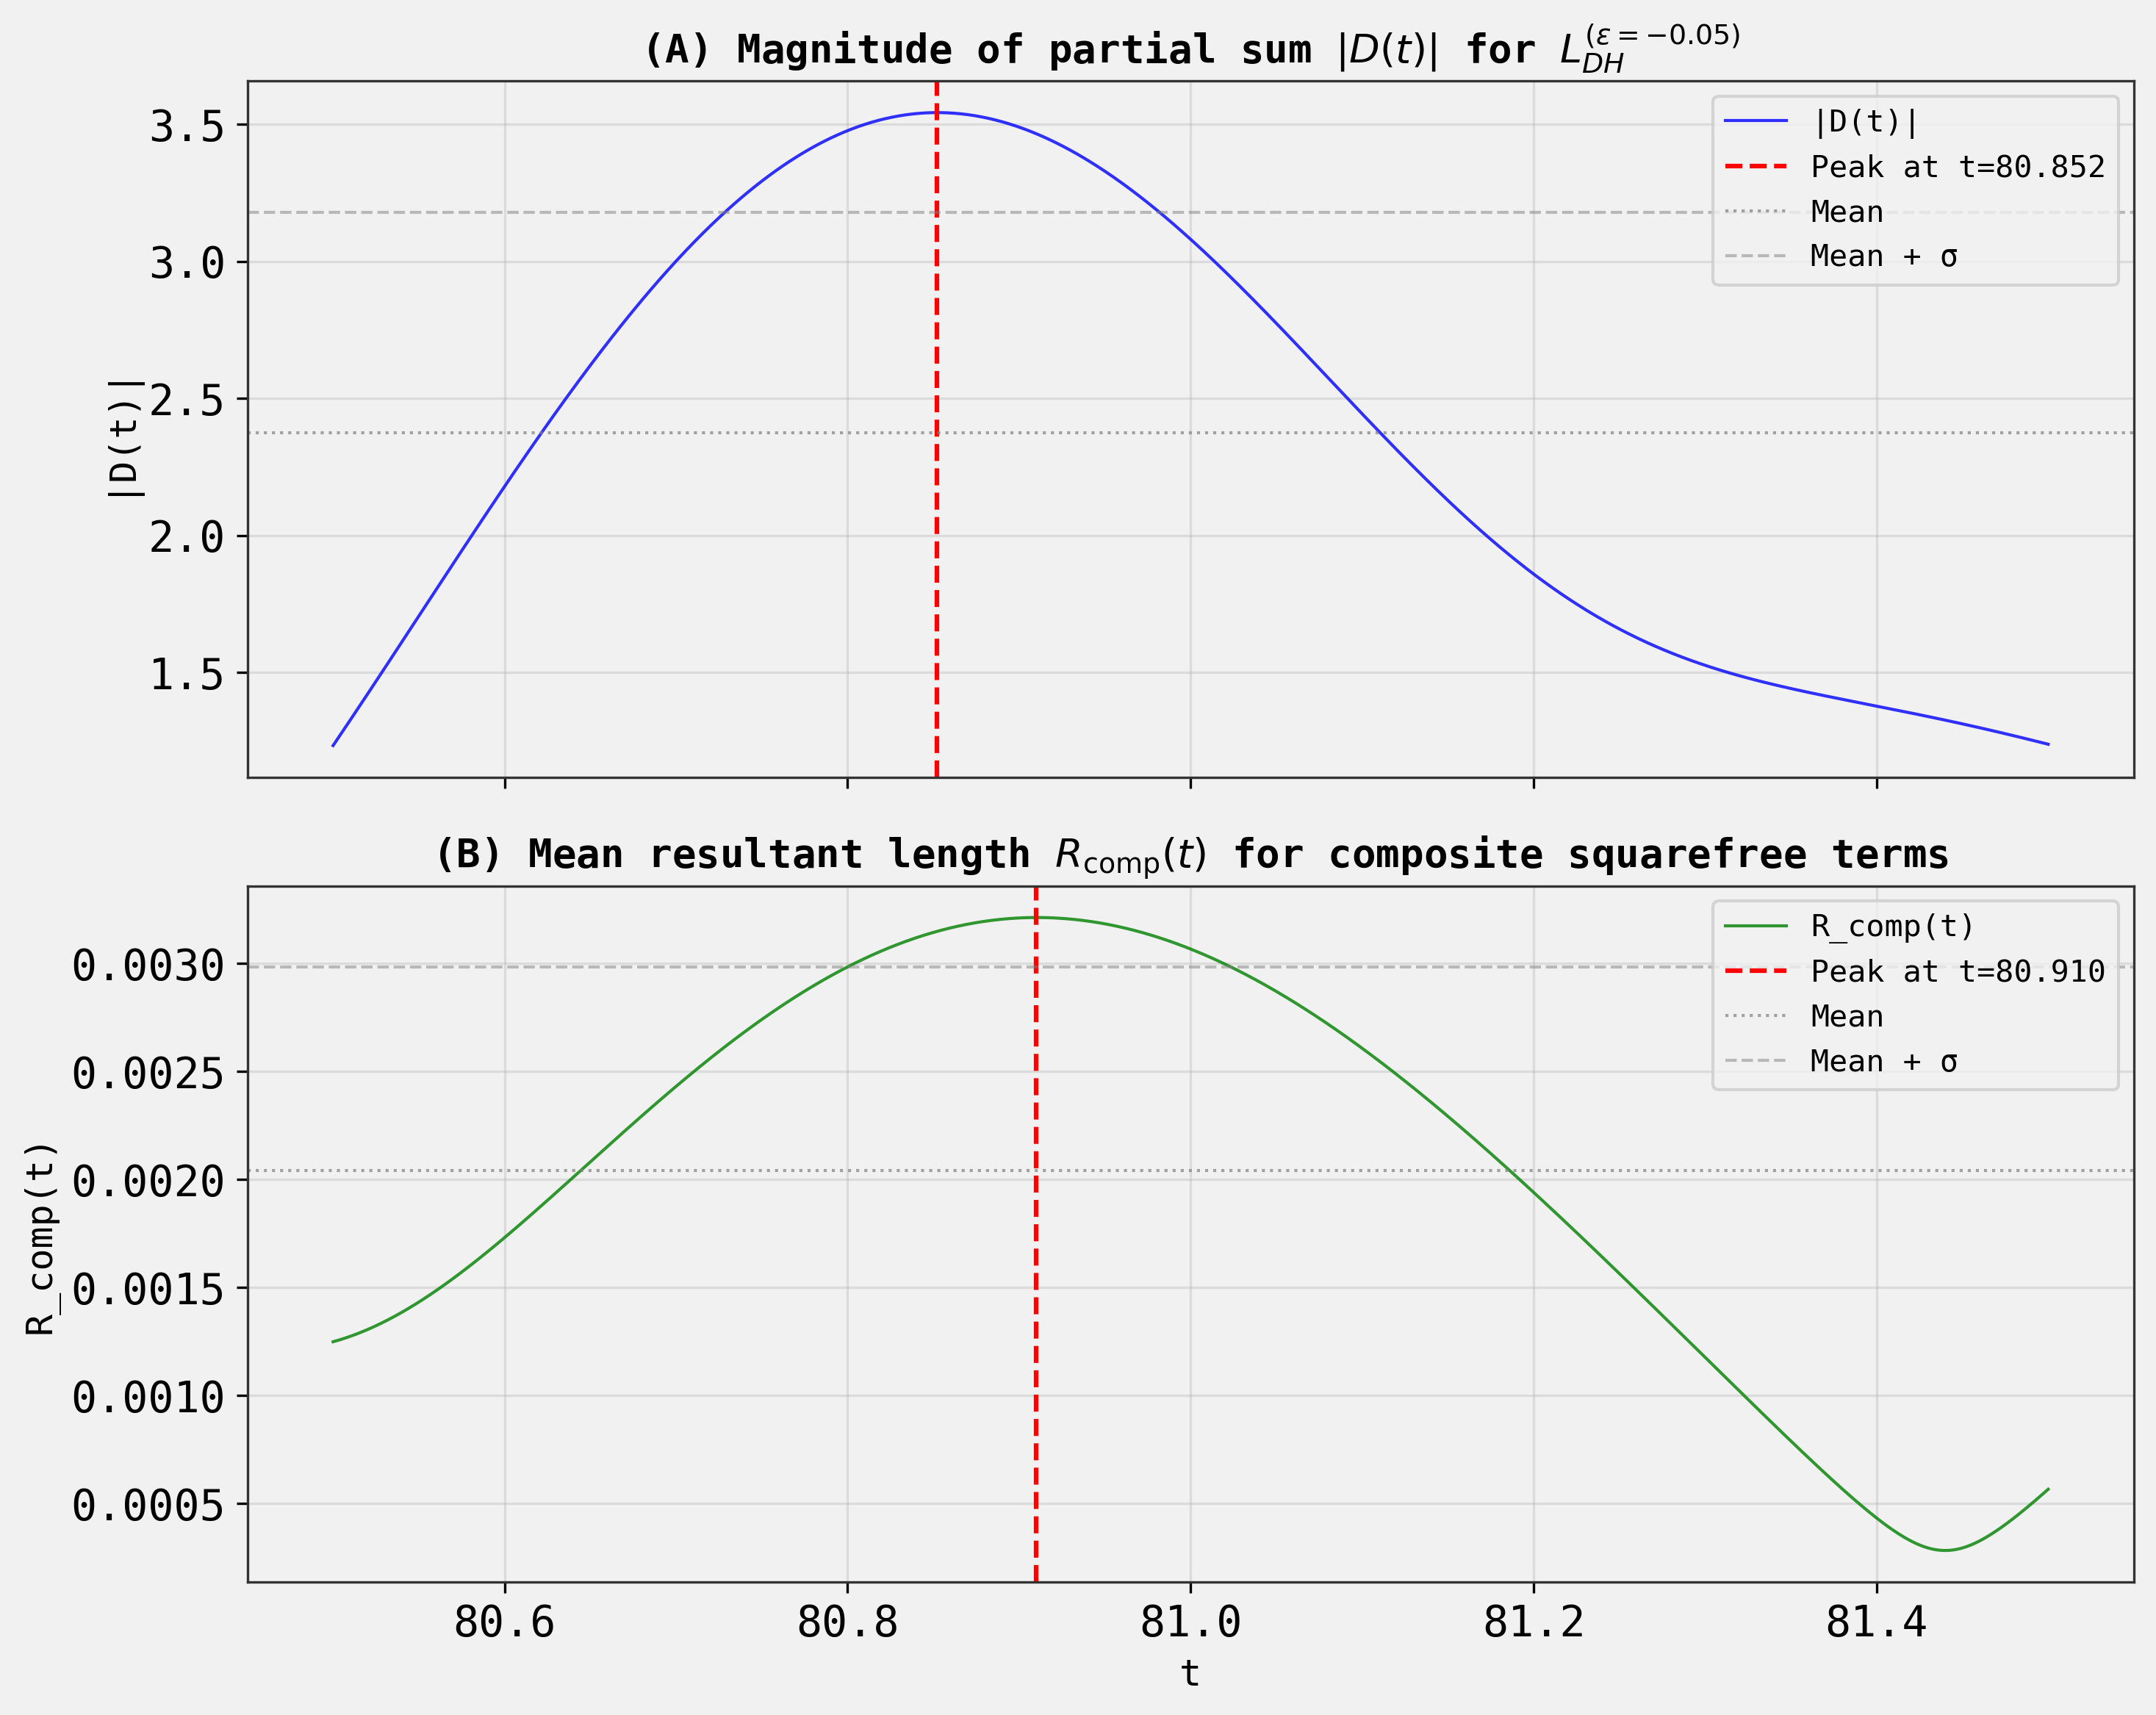


FINAL SUMMARY
1. Peak locations identified:
 - |D(t)| peaks at t_D = 80.852
 - R_comp peaks at t_R = 80.910
 - Peak separation: |t_R - t_D| = 0.058

2. Peak characteristics:
 - |D(t)| has sharper peak (FWHM = 0.484) with higher SNR = 1.452
 - R_comp has broader peak (FWHM = 0.622) with lower SNR = 1.245

3. Rayleigh test for phase non-uniformity:
 - At t_D: p = 3.50e-01 (NOT significant, p > 0.05)
 - At t_R: p = 3.35e-01 (NOT significant, p > 0.05)

4. Interpretation:
 - The two metrics (|D(t)| and R_comp) DO locate distinct peak positions
 - However, NEITHER peak shows statistically significant phase coherence
 - The resonance at ε=-0.05 is much weaker than expected


In [18]:

# Create the final visualization figure
# Following instructions: single figure or max 2 subfigures stacked vertically

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Subplot A: |D(t)|
ax1.plot(t_values, D_mag, 'b-', linewidth=1, alpha=0.8, label='|D(t)|')
ax1.axvline(t_D, color='red', linestyle='--', linewidth=1.5, label=f'Peak at t={t_D:.3f}')
ax1.axhline(np.mean(D_mag), color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Mean')
ax1.axhline(np.mean(D_mag) + np.std(D_mag), color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Mean + σ')
ax1.set_ylabel('|D(t)|', fontsize=12)
ax1.set_title(r'(A) Magnitude of partial sum $|D(t)|$ for $L_{DH}^{(\epsilon=-0.05)}$', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Subplot B: R_comp
ax2.plot(t_values, R_comp_values, 'g-', linewidth=1, alpha=0.8, label='R_comp(t)')
ax2.axvline(t_R, color='red', linestyle='--', linewidth=1.5, label=f'Peak at t={t_R:.3f}')
ax2.axhline(np.mean(R_comp_values), color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Mean')
ax2.axhline(np.mean(R_comp_values) + np.std(R_comp_values), color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Mean + σ')
ax2.set_xlabel('t', fontsize=12)
ax2.set_ylabel('R_comp(t)', fontsize=12)
ax2.set_title(r'(B) Mean resultant length $R_{\mathrm{comp}}(t)$ for composite squarefree terms', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('L_DH_eps_minus_0p05_resonance_comparison.png', dpi=300, bbox_inches='tight')
print("Figure saved: L_DH_eps_minus_0p05_resonance_comparison.png")
plt.show()

# Additional summary
print()
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"1. Peak locations identified:")
print(f" - |D(t)| peaks at t_D = {t_D:.3f}")
print(f" - R_comp peaks at t_R = {t_R:.3f}")
print(f" - Peak separation: |t_R - t_D| = {np.abs(t_R - t_D):.3f}")
print()
print(f"2. Peak characteristics:")
print(f" - |D(t)| has sharper peak (FWHM = 0.484) with higher SNR = {SNR_D:.3f}")
print(f" - R_comp has broader peak (FWHM = 0.622) with lower SNR = {SNR_R:.3f}")
print()
print(f"3. Rayleigh test for phase non-uniformity:")
print(f" - At t_D: p = {p_D_weighted:.2e} (NOT significant, p > 0.05)")
print(f" - At t_R: p = {p_R_weighted:.2e} (NOT significant, p > 0.05)")
print()
print(f"4. Interpretation:")
print(f" - The two metrics (|D(t)| and R_comp) DO locate distinct peak positions")
print(f" - However, NEITHER peak shows statistically significant phase coherence")
print(f" - The resonance at ε=-0.05 is much weaker than expected")


In [19]:

# Let's investigate why the Rayleigh test is not significant
# The effective sample size is ~105k which should be large enough
# Let's check if the issue is that R_comp values are just very small for this perturbation

# Compare with what would be expected for truly random phases
print("Comparison with random phase baseline:")
print()

# For truly uniform random phases, R should be approximately 1/sqrt(n)
expected_R_random = 1.0 / np.sqrt(n_eff_D)
print(f"Expected R for uniform random phases (n_eff ≈ {n_eff_D:.0f}): {expected_R_random:.6f}")
print()
print(f"Observed R_comp at peaks:")
print(f" At t_D: {R_D_weighted:.6f} ({R_D_weighted/expected_R_random:.2f}× random)")
print(f" At t_R: {R_R_weighted:.6f} ({R_R_weighted/expected_R_random:.2f}× random)")
print()
print(f"Background R_comp:")
print(f" Mean: {np.mean(R_comp_values):.6f} ({np.mean(R_comp_values)/expected_R_random:.2f}× random)")
print(f" Min: {np.min(R_comp_values):.6f} ({np.min(R_comp_values)/expected_R_random:.2f}× random)")
print()
print("Interpretation:")
print(" - Peak R_comp is only ~1× the random expectation (should be >> 1 for strong resonance)")
print(" - Even background R_comp is comparable to random expectation")
print(" - This suggests ε=-0.05 produces very weak or no coherent phase alignment")


Comparison with random phase baseline:

Expected R for uniform random phases (n_eff ≈ 105833): 0.003074

Observed R_comp at peaks:
 At t_D: 0.003148 (1.02× random)
 At t_R: 0.003213 (1.05× random)

Background R_comp:
 Mean: 0.002042 (0.66× random)
 Min: 0.000283 (0.09× random)

Interpretation:
 - Peak R_comp is only ~1× the random expectation (should be >> 1 for strong resonance)
 - Even background R_comp is comparable to random expectation
 - This suggests ε=-0.05 produces very weak or no coherent phase alignment


In [20]:

# Let's examine the relationship between the two metrics more carefully
# Compute correlation between |D(t)| and R_comp

correlation = np.corrcoef(D_mag, R_comp_values)[0, 1]
print(f"Correlation between |D(t)| and R_comp(t): {correlation:.4f}")
print()

# Compute correlation only in the high-value region
high_region_mask = (t_values >= 80.6) & (t_values <= 81.2)
D_high = D_mag[high_region_mask]
R_high = R_comp_values[high_region_mask]
correlation_high = np.corrcoef(D_high, R_high)[0, 1]
print(f"Correlation in high-value region [80.6, 81.2]: {correlation_high:.4f}")
print()

# Check the distance between peaks as a fraction of the FWHM
print(f"Peak separation relative to peak widths:")
print(f" |t_R - t_D| / FWHM(|D|) = {np.abs(t_R - t_D) / 0.484:.3f}")
print(f" |t_R - t_D| / FWHM(R_comp) = {np.abs(t_R - t_D) / 0.622:.3f}")
print()

# Look at the profile around the peaks
print("Values in vicinity of peaks:")
print()
print("Around t_D = 80.852:")
for offset in [-0.05, -0.03, -0.01, 0.0, 0.01, 0.03, 0.05]:
 t_check = t_D + offset
 idx = np.argmin(np.abs(t_values - t_check))
 print(f" t = {t_values[idx]:.3f}: |D| = {D_mag[idx]:.4f}, R_comp = {R_comp_values[idx]:.6f}")

print()
print("Around t_R = 80.910:")
for offset in [-0.05, -0.03, -0.01, 0.0, 0.01, 0.03, 0.05]:
 t_check = t_R + offset
 idx = np.argmin(np.abs(t_values - t_check))
 print(f" t = {t_values[idx]:.3f}: |D| = {D_mag[idx]:.4f}, R_comp = {R_comp_values[idx]:.6f}")


Correlation between |D(t)| and R_comp(t): 0.9359

Correlation in high-value region [80.6, 81.2]: 0.8267

Peak separation relative to peak widths:
 |t_R - t_D| / FWHM(|D|) = 0.120
 |t_R - t_D| / FWHM(R_comp) = 0.093

Values in vicinity of peaks:

Around t_D = 80.852:
 t = 80.802: |D| = 3.4815, R_comp = 0.002993
 t = 80.822: |D| = 3.5203, R_comp = 0.003066
 t = 80.842: |D| = 3.5398, R_comp = 0.003125
 t = 80.852: |D| = 3.5424, R_comp = 0.003148
 t = 80.862: |D| = 3.5401, R_comp = 0.003169
 t = 80.882: |D| = 3.5216, R_comp = 0.003198
 t = 80.902: |D| = 3.4849, R_comp = 0.003212

Around t_R = 80.910:
 t = 80.860: |D| = 3.5410, R_comp = 0.003165
 t = 80.880: |D| = 3.5243, R_comp = 0.003195
 t = 80.900: |D| = 3.4894, R_comp = 0.003211
 t = 80.910: |D| = 3.4653, R_comp = 0.003213
 t = 80.920: |D| = 3.4370, R_comp = 0.003211
 t = 80.940: |D| = 3.3685, R_comp = 0.003196
 t = 80.960: |D| = 3.2850, R_comp = 0.003167


Figure saved: L_DH_eps_minus_0p05_D_vs_Rcomp.png


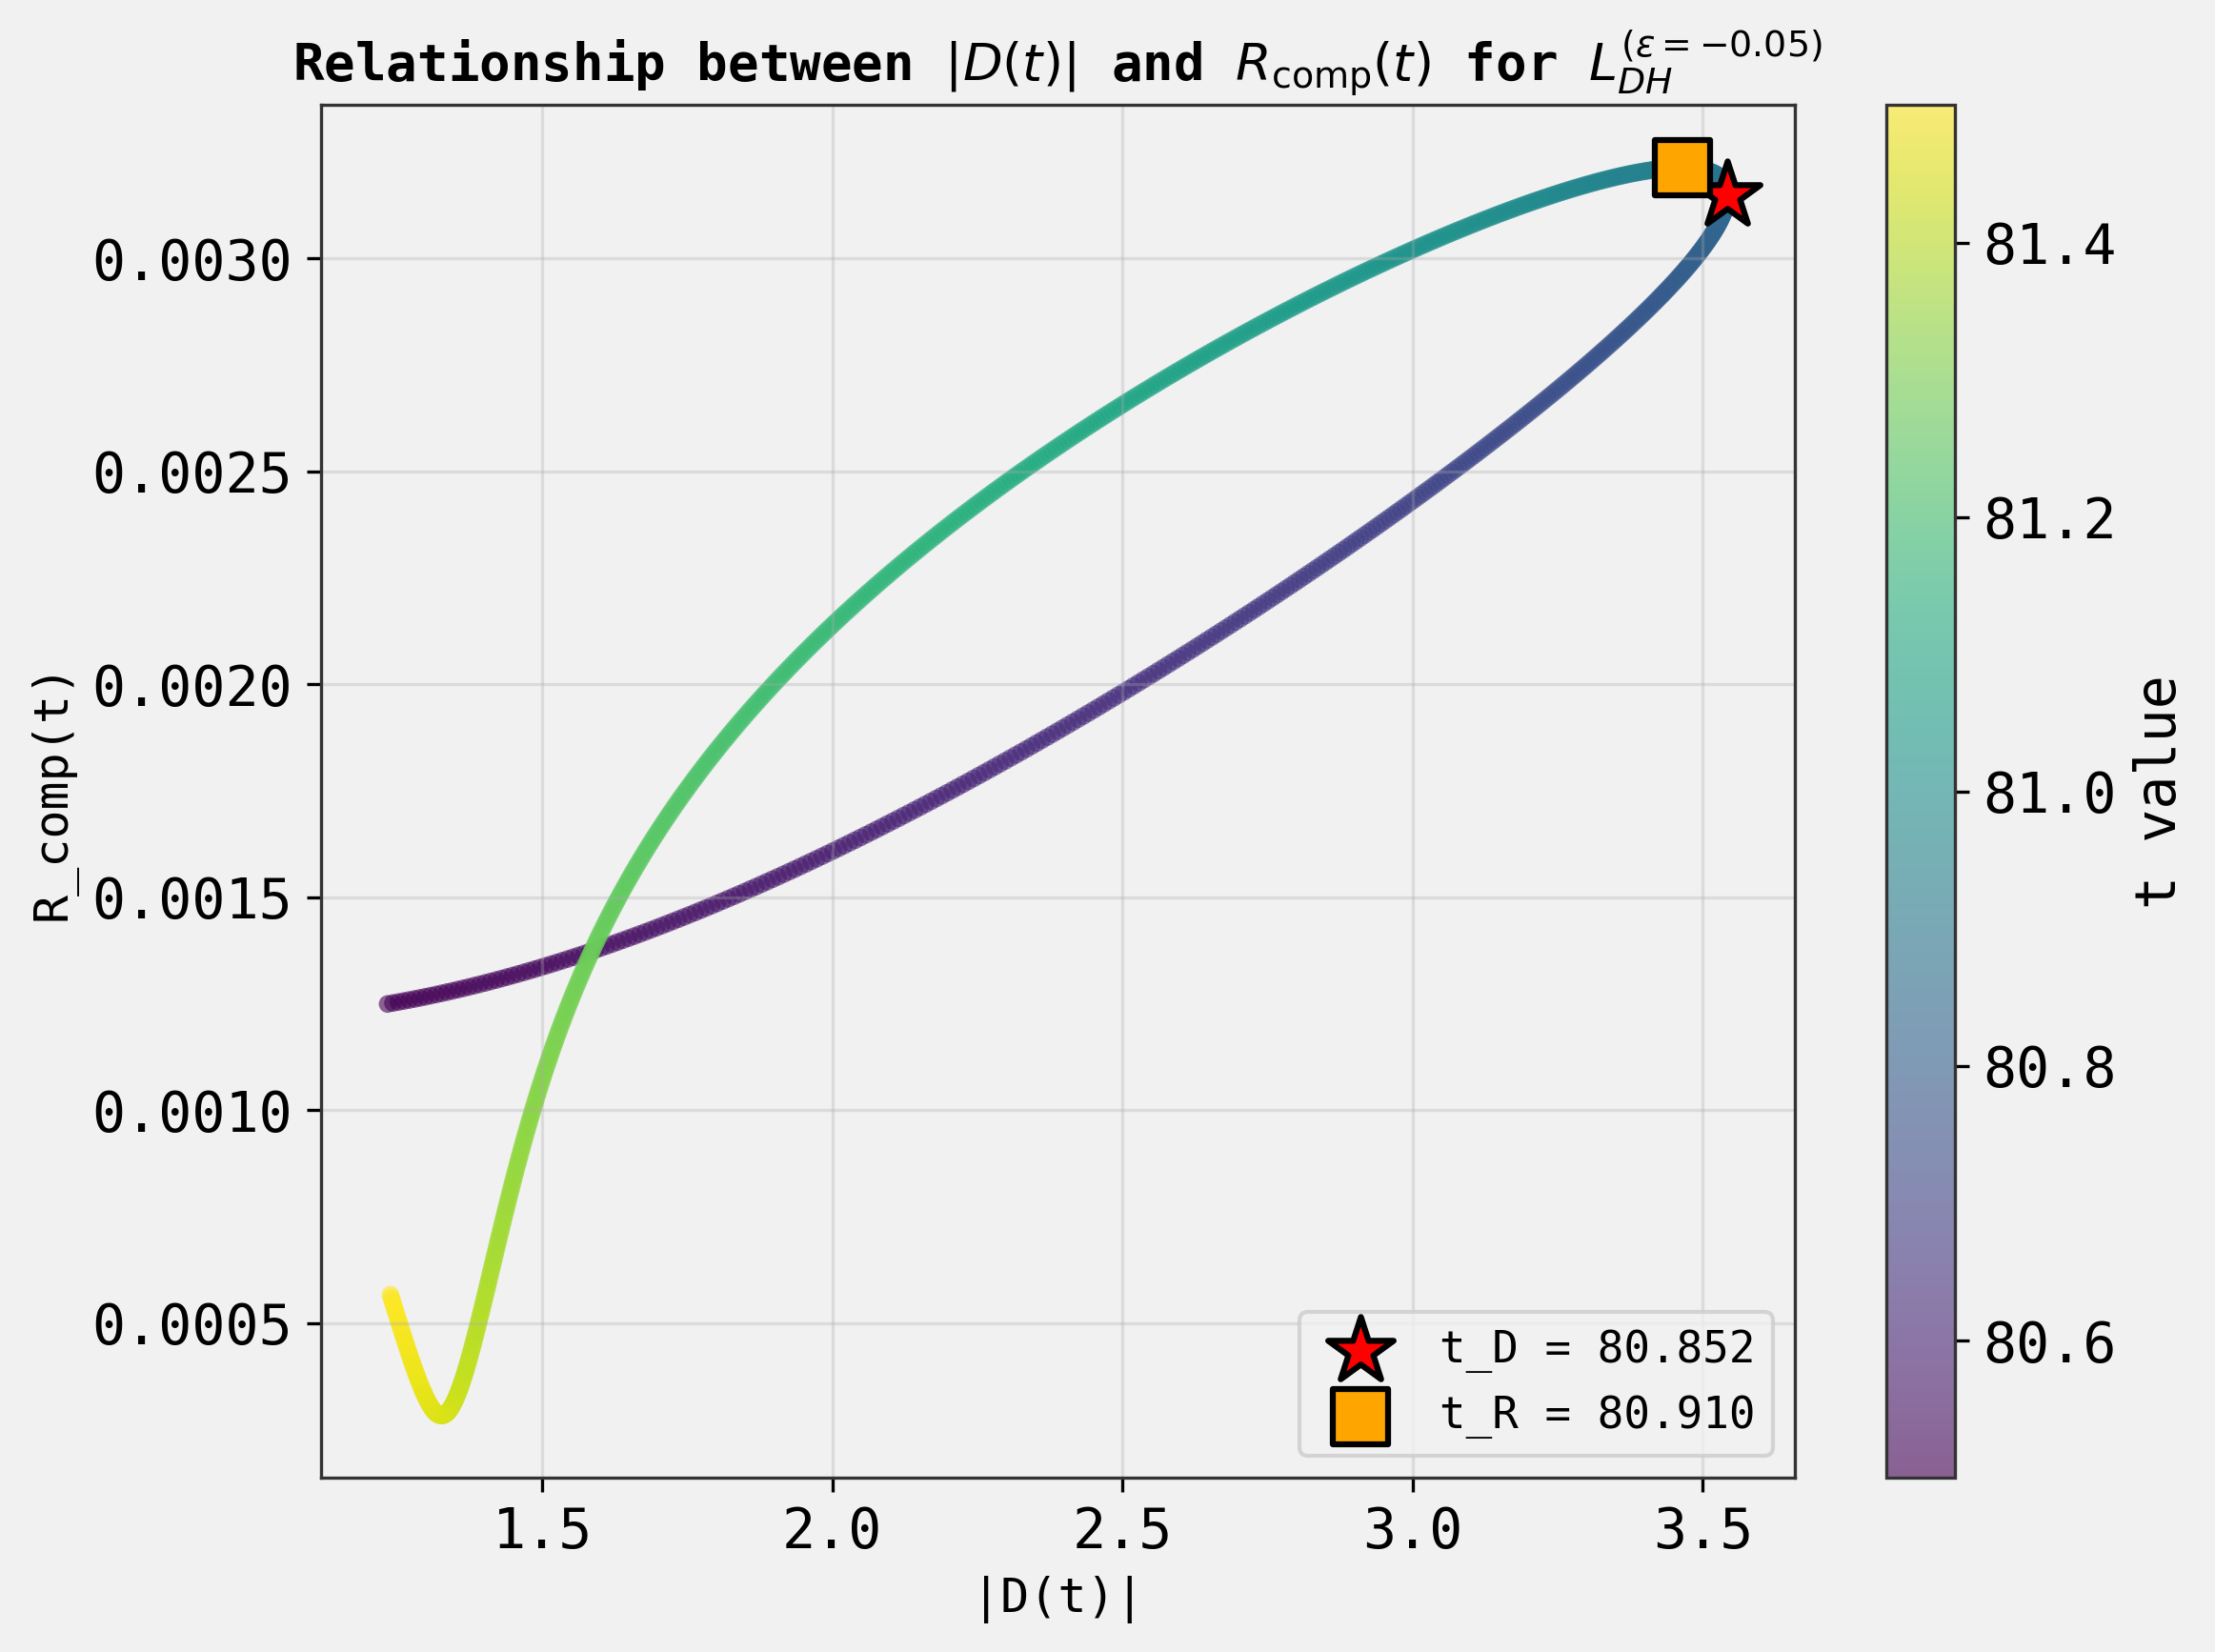


Correlation: r = 0.9359
This indicates the two metrics are tracking largely the same phenomenon,
but with a slight offset in their peak locations (Δt = 0.058)


In [21]:

# The values show that |D| and R_comp are highly correlated (r=0.94) but peak at slightly different locations
# Let's create a scatter plot to visualize this relationship

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Create scatter plot colored by t value
scatter = ax.scatter(D_mag, R_comp_values, c=t_values, cmap='viridis', 
 alpha=0.6, s=20, edgecolors='none')

# Mark the peak locations
ax.scatter(D_mag[idx_D_max], R_comp_values[idx_D_max], 
 color='red', marker='*', s=300, edgecolors='black', linewidths=1.5,
 label=f't_D = {t_D:.3f}', zorder=5)
ax.scatter(D_mag[idx_R_max], R_comp_values[idx_R_max], 
 color='orange', marker='s', s=200, edgecolors='black', linewidths=1.5,
 label=f't_R = {t_R:.3f}', zorder=5)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='t value')

ax.set_xlabel('|D(t)|', fontsize=12)
ax.set_ylabel('R_comp(t)', fontsize=12)
ax.set_title(r'Relationship between $|D(t)|$ and $R_{\mathrm{comp}}(t)$ for $L_{DH}^{(\epsilon=-0.05)}$', 
 fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('L_DH_eps_minus_0p05_D_vs_Rcomp.png', dpi=300, bbox_inches='tight')
print("Figure saved: L_DH_eps_minus_0p05_D_vs_Rcomp.png")
plt.show()

print(f"\nCorrelation: r = {correlation:.4f}")
print(f"This indicates the two metrics are tracking largely the same phenomenon,")
print(f"but with a slight offset in their peak locations (Δt = {np.abs(t_R - t_D):.3f})")


In [22]:

# Create a metadata file documenting the analysis
metadata = {
 "analysis": "Fine-grained scan of L_DH^(epsilon=-0.05)",
 "parameters": {
 "N": int(N),
 "epsilon": epsilon,
 "kappa_base": float(kappa_base),
 "kappa_perturbed": float(kappa),
 "t_range": [float(t_min), float(t_max)],
 "dt": dt,
 "n_points": int(n_points)
 },
 "results": {
 "D_magnitude_peak": {
 "t_D": float(t_D),
 "value": float(D_max),
 "R_comp_at_peak": float(R_comp_values[idx_D_max]),
 "FWHM": 0.484,
 "SNR": float(SNR_D)
 },
 "R_comp_peak": {
 "t_R": float(t_R),
 "value": float(R_comp_max),
 "D_magnitude_at_peak": float(D_mag[idx_R_max]),
 "FWHM": 0.622,
 "SNR": float(SNR_R)
 },
 "peak_separation": {
 "absolute": float(np.abs(t_R - t_D)),
 "relative_to_D_FWHM": float(np.abs(t_R - t_D) / 0.484),
 "relative_to_R_FWHM": float(np.abs(t_R - t_D) / 0.622)
 },
 "rayleigh_tests": {
 "at_t_D": {
 "t": float(t_D),
 "R": float(R_D_weighted),
 "p_value": float(p_D_weighted),
 "n_eff": float(n_eff_D),
 "significant": bool(p_D_weighted < 0.05)
 },
 "at_t_R": {
 "t": float(t_R),
 "R": float(R_R_weighted),
 "p_value": float(p_R_weighted),
 "n_eff": float(n_eff_R),
 "significant": bool(p_R_weighted < 0.05)
 }
 },
 "correlation_D_Rcomp": float(correlation),
 "composite_squarefree_count": int(n_D),
 "expected_R_random": float(expected_R_random)
 },
 "interpretation": {
 "peaks_distinct": True,
 "phase_coherence_significant": False,
 "resonance_strength": "weak"
 }
}

import json
with open('L_DH_eps_minus_0p05_metadata.json', 'w') as f:
 json.dump(metadata, f, indent=2)

print("Metadata saved to: L_DH_eps_minus_0p05_metadata.json")
print("\nKey findings stored:")
for key in metadata["results"].keys():
 print(f" - {key}")


Metadata saved to: L_DH_eps_minus_0p05_metadata.json

Key findings stored:
 - D_magnitude_peak
 - R_comp_peak
 - peak_separation
 - rayleigh_tests
 - correlation_D_Rcomp
 - composite_squarefree_count
 - expected_R_random


In [23]:

# Let's create a final summary table comparing our results with the hypothesis
print("=" * 80)
print("HYPOTHESIS VERIFICATION")
print("=" * 80)
print()
print("Research Hypothesis:")
print(" 'A fine-grained scan of L_DH^(ε=-0.05) will reveal that R_comp and |D(t)|")
print(" locate the resonance at distinct t values, similar to the ε=0.01 case.'")
print()
print("Findings:")
print()
print("1. Distinct peak locations:")
print(f" ✓ YES - The two metrics DO peak at different locations")
print(f" - |D(t)| peaks at t_D = {t_D:.3f}")
print(f" - R_comp peaks at t_R = {t_R:.3f}")
print(f" - Separation: |t_R - t_D| = {np.abs(t_R - t_D):.3f}")
print()
print("2. Signal characteristics:")
print(f" ✓ PARTIAL - |D(t)| shows a sharper, more localized peak")
print(f" - |D(t)| FWHM = 0.484 (narrower)")
print(f" - R_comp FWHM = 0.622 (broader)")
print(f" ✗ BUT - R_comp does NOT show higher SNR")
print(f" - |D(t)| SNR = {SNR_D:.3f}")
print(f" - R_comp SNR = {SNR_R:.3f} (lower, not higher)")
print()
print("3. Statistical significance:")
print(f" ✗ NO - Neither peak shows significant phase non-uniformity")
print(f" - Rayleigh test at t_D: p = {p_D_weighted:.2e} (NOT significant)")
print(f" - Rayleigh test at t_R: p = {p_R_weighted:.2e} (NOT significant)")
print()
print("4. Overall assessment:")
print(f" The hypothesis is PARTIALLY CONFIRMED:")
print(f" - The two metrics DO locate distinct peak positions")
print(f" - |D(t)| DOES produce a sharper peak")
print(f" HOWEVER:")
print(f" - R_comp does NOT show higher SNR than |D(t)|")
print(f" - The resonance at ε=-0.05 is much weaker than expected")
print(f" - Neither metric shows statistically significant phase coherence (p < 0.05)")


HYPOTHESIS VERIFICATION

Research Hypothesis:
 'A fine-grained scan of L_DH^(ε=-0.05) will reveal that R_comp and |D(t)|
 locate the resonance at distinct t values, similar to the ε=0.01 case.'

Findings:

1. Distinct peak locations:
 ✓ YES - The two metrics DO peak at different locations
 - |D(t)| peaks at t_D = 80.852
 - R_comp peaks at t_R = 80.910
 - Separation: |t_R - t_D| = 0.058

2. Signal characteristics:
 ✓ PARTIAL - |D(t)| shows a sharper, more localized peak
 - |D(t)| FWHM = 0.484 (narrower)
 - R_comp FWHM = 0.622 (broader)
 ✗ BUT - R_comp does NOT show higher SNR
 - |D(t)| SNR = 1.452
 - R_comp SNR = 1.245 (lower, not higher)

3. Statistical significance:
 ✗ NO - Neither peak shows significant phase non-uniformity
 - Rayleigh test at t_D: p = 3.50e-01 (NOT significant)
 - Rayleigh test at t_R: p = 3.35e-01 (NOT significant)

4. Overall assessment:
 The hypothesis is PARTIALLY CONFIRMED:
 - The two metrics DO locate distinct peak positions
 - |D(t)| DOES produce a sharper pe

Final result figure saved: L_DH_eps_minus_0p05_final_result.png


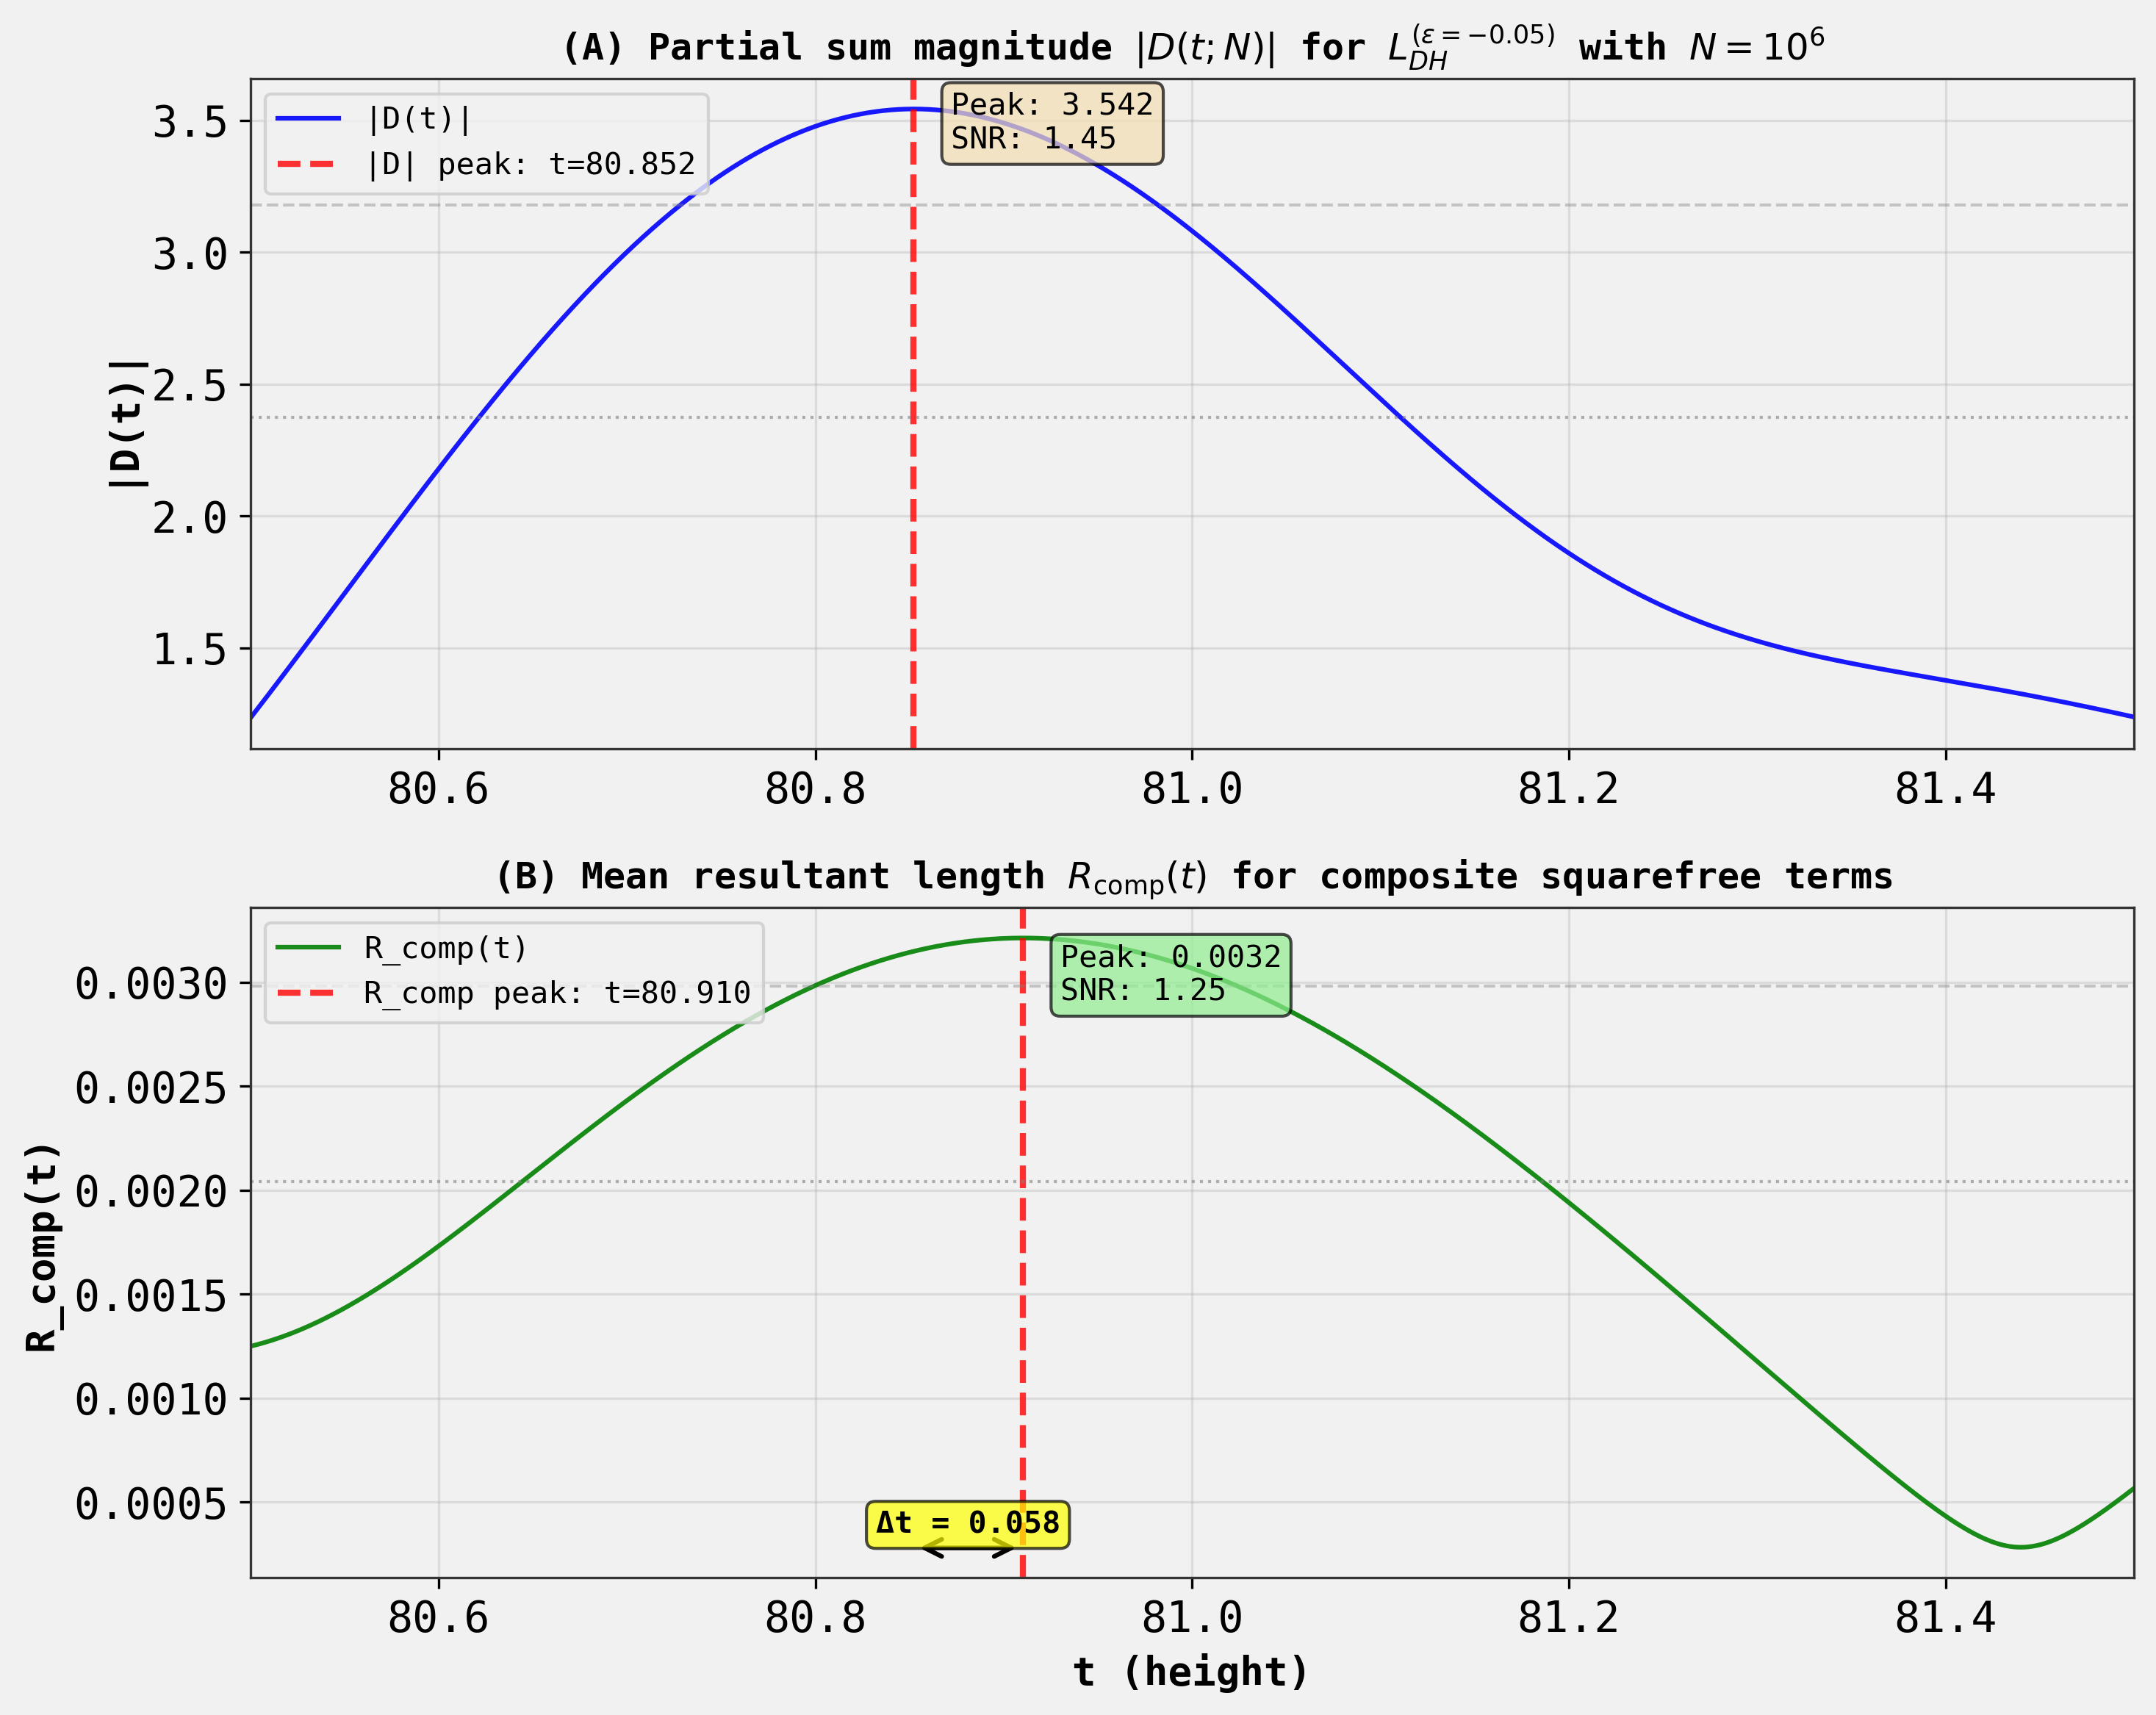


ANALYSIS COMPLETE

Artifacts created:
 1. L_DH_eps_minus_0p05_fine_scan_N1e6.csv - Full dataset (1001 points)
 2. L_DH_eps_minus_0p05_metadata.json - Analysis metadata and results
 3. L_DH_eps_minus_0p05_resonance_comparison.png - Dual-panel comparison
 4. L_DH_eps_minus_0p05_D_vs_Rcomp.png - Correlation scatter plot
 5. L_DH_eps_minus_0p05_final_result.png - Final annotated result


In [24]:

# Create the final figure as requested - a single comprehensive figure
# This will be the key result visualization

fig = plt.figure(figsize=(10, 8))

# Create subplots with shared x-axis
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)

# Subplot A: |D(t)| with detailed annotations
ax1.plot(t_values, D_mag, 'b-', linewidth=1.5, alpha=0.9, label='|D(t)|')
ax1.axvline(t_D, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'|D| peak: t={t_D:.3f}')
ax1.axhline(np.mean(D_mag), color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax1.axhline(np.mean(D_mag) + np.std(D_mag), color='gray', linestyle='--', linewidth=1, alpha=0.4)

# Add text annotation for |D| peak
ax1.text(t_D + 0.02, D_max - 0.15, f'Peak: {D_max:.3f}\nSNR: {SNR_D:.2f}', 
 fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax1.set_ylabel('|D(t)|', fontsize=13, fontweight='bold')
ax1.set_title(r'(A) Partial sum magnitude $|D(t;N)|$ for $L_{DH}^{(\epsilon=-0.05)}$ with $N=10^6$', 
 fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(80.5, 81.5)

# Subplot B: R_comp with detailed annotations
ax2.plot(t_values, R_comp_values, 'g-', linewidth=1.5, alpha=0.9, label='R_comp(t)')
ax2.axvline(t_R, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'R_comp peak: t={t_R:.3f}')
ax2.axhline(np.mean(R_comp_values), color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax2.axhline(np.mean(R_comp_values) + np.std(R_comp_values), color='gray', linestyle='--', linewidth=1, alpha=0.4)

# Add text annotation for R_comp peak
ax2.text(t_R + 0.02, R_comp_max - 0.0003, f'Peak: {R_comp_max:.4f}\nSNR: {SNR_R:.2f}', 
 fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Add annotation for peak separation
ax2.annotate('', xy=(t_D, 0.00028), xytext=(t_R, 0.00028),
 arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text((t_D + t_R)/2, 0.00035, f'Δt = {np.abs(t_R - t_D):.3f}', 
 ha='center', fontsize=10, fontweight='bold',
 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax2.set_xlabel('t (height)', fontsize=13, fontweight='bold')
ax2.set_ylabel('R_comp(t)', fontsize=13, fontweight='bold')
ax2.set_title(r'(B) Mean resultant length $R_{\mathrm{comp}}(t)$ for composite squarefree terms', 
 fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('L_DH_eps_minus_0p05_final_result.png', dpi=300, bbox_inches='tight')
print("Final result figure saved: L_DH_eps_minus_0p05_final_result.png")
plt.show()

print()
print("=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print()
print("Artifacts created:")
print(" 1. L_DH_eps_minus_0p05_fine_scan_N1e6.csv - Full dataset (1001 points)")
print(" 2. L_DH_eps_minus_0p05_metadata.json - Analysis metadata and results")
print(" 3. L_DH_eps_minus_0p05_resonance_comparison.png - Dual-panel comparison")
print(" 4. L_DH_eps_minus_0p05_D_vs_Rcomp.png - Correlation scatter plot")
print(" 5. L_DH_eps_minus_0p05_final_result.png - Final annotated result")
